In [20]:
# 1. Data Manipulation and Analysis
import pandas as pd
import numpy as np

# 2. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning (Scikit-Learn)
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Ensure plots appear correctly inside the notebook
%matplotlib inline


load dataset

In [7]:
from sklearn.datasets import fetch_openml
boston = fetch_openml(name='boston', version=1, as_frame=True)
print(boston.data.head())
print(boston.target.head())

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64


In [9]:
boston.data.keys()

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='str')

Lets check the description of the datasets

In [10]:
print(boston.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

Prepare the dataset

In [3]:
import pandas as pd
from sklearn.datasets import fetch_openml

# 1. Download the dataset
boston = fetch_openml(name='boston', version=1, as_frame=True)

# 2. Convert it to a Pandas DataFrame
dataset = pd.DataFrame(boston.data)

# 3. View the first 5 rows
print(dataset.head())


      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  


In [4]:
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [6]:
dataset = pd.DataFrame(boston.data, columns=boston.feature_names)
print(dataset.head())


      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  


In [7]:
dataset['price']=boston.target

In [8]:
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [9]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  price    506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 48.6 KB


Summerizing stats of the data

In [10]:
dataset.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


Check the missing values

In [12]:
dataset.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
price      0
dtype: int64

EDA= exploratry data analisys

In [13]:
dataset.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


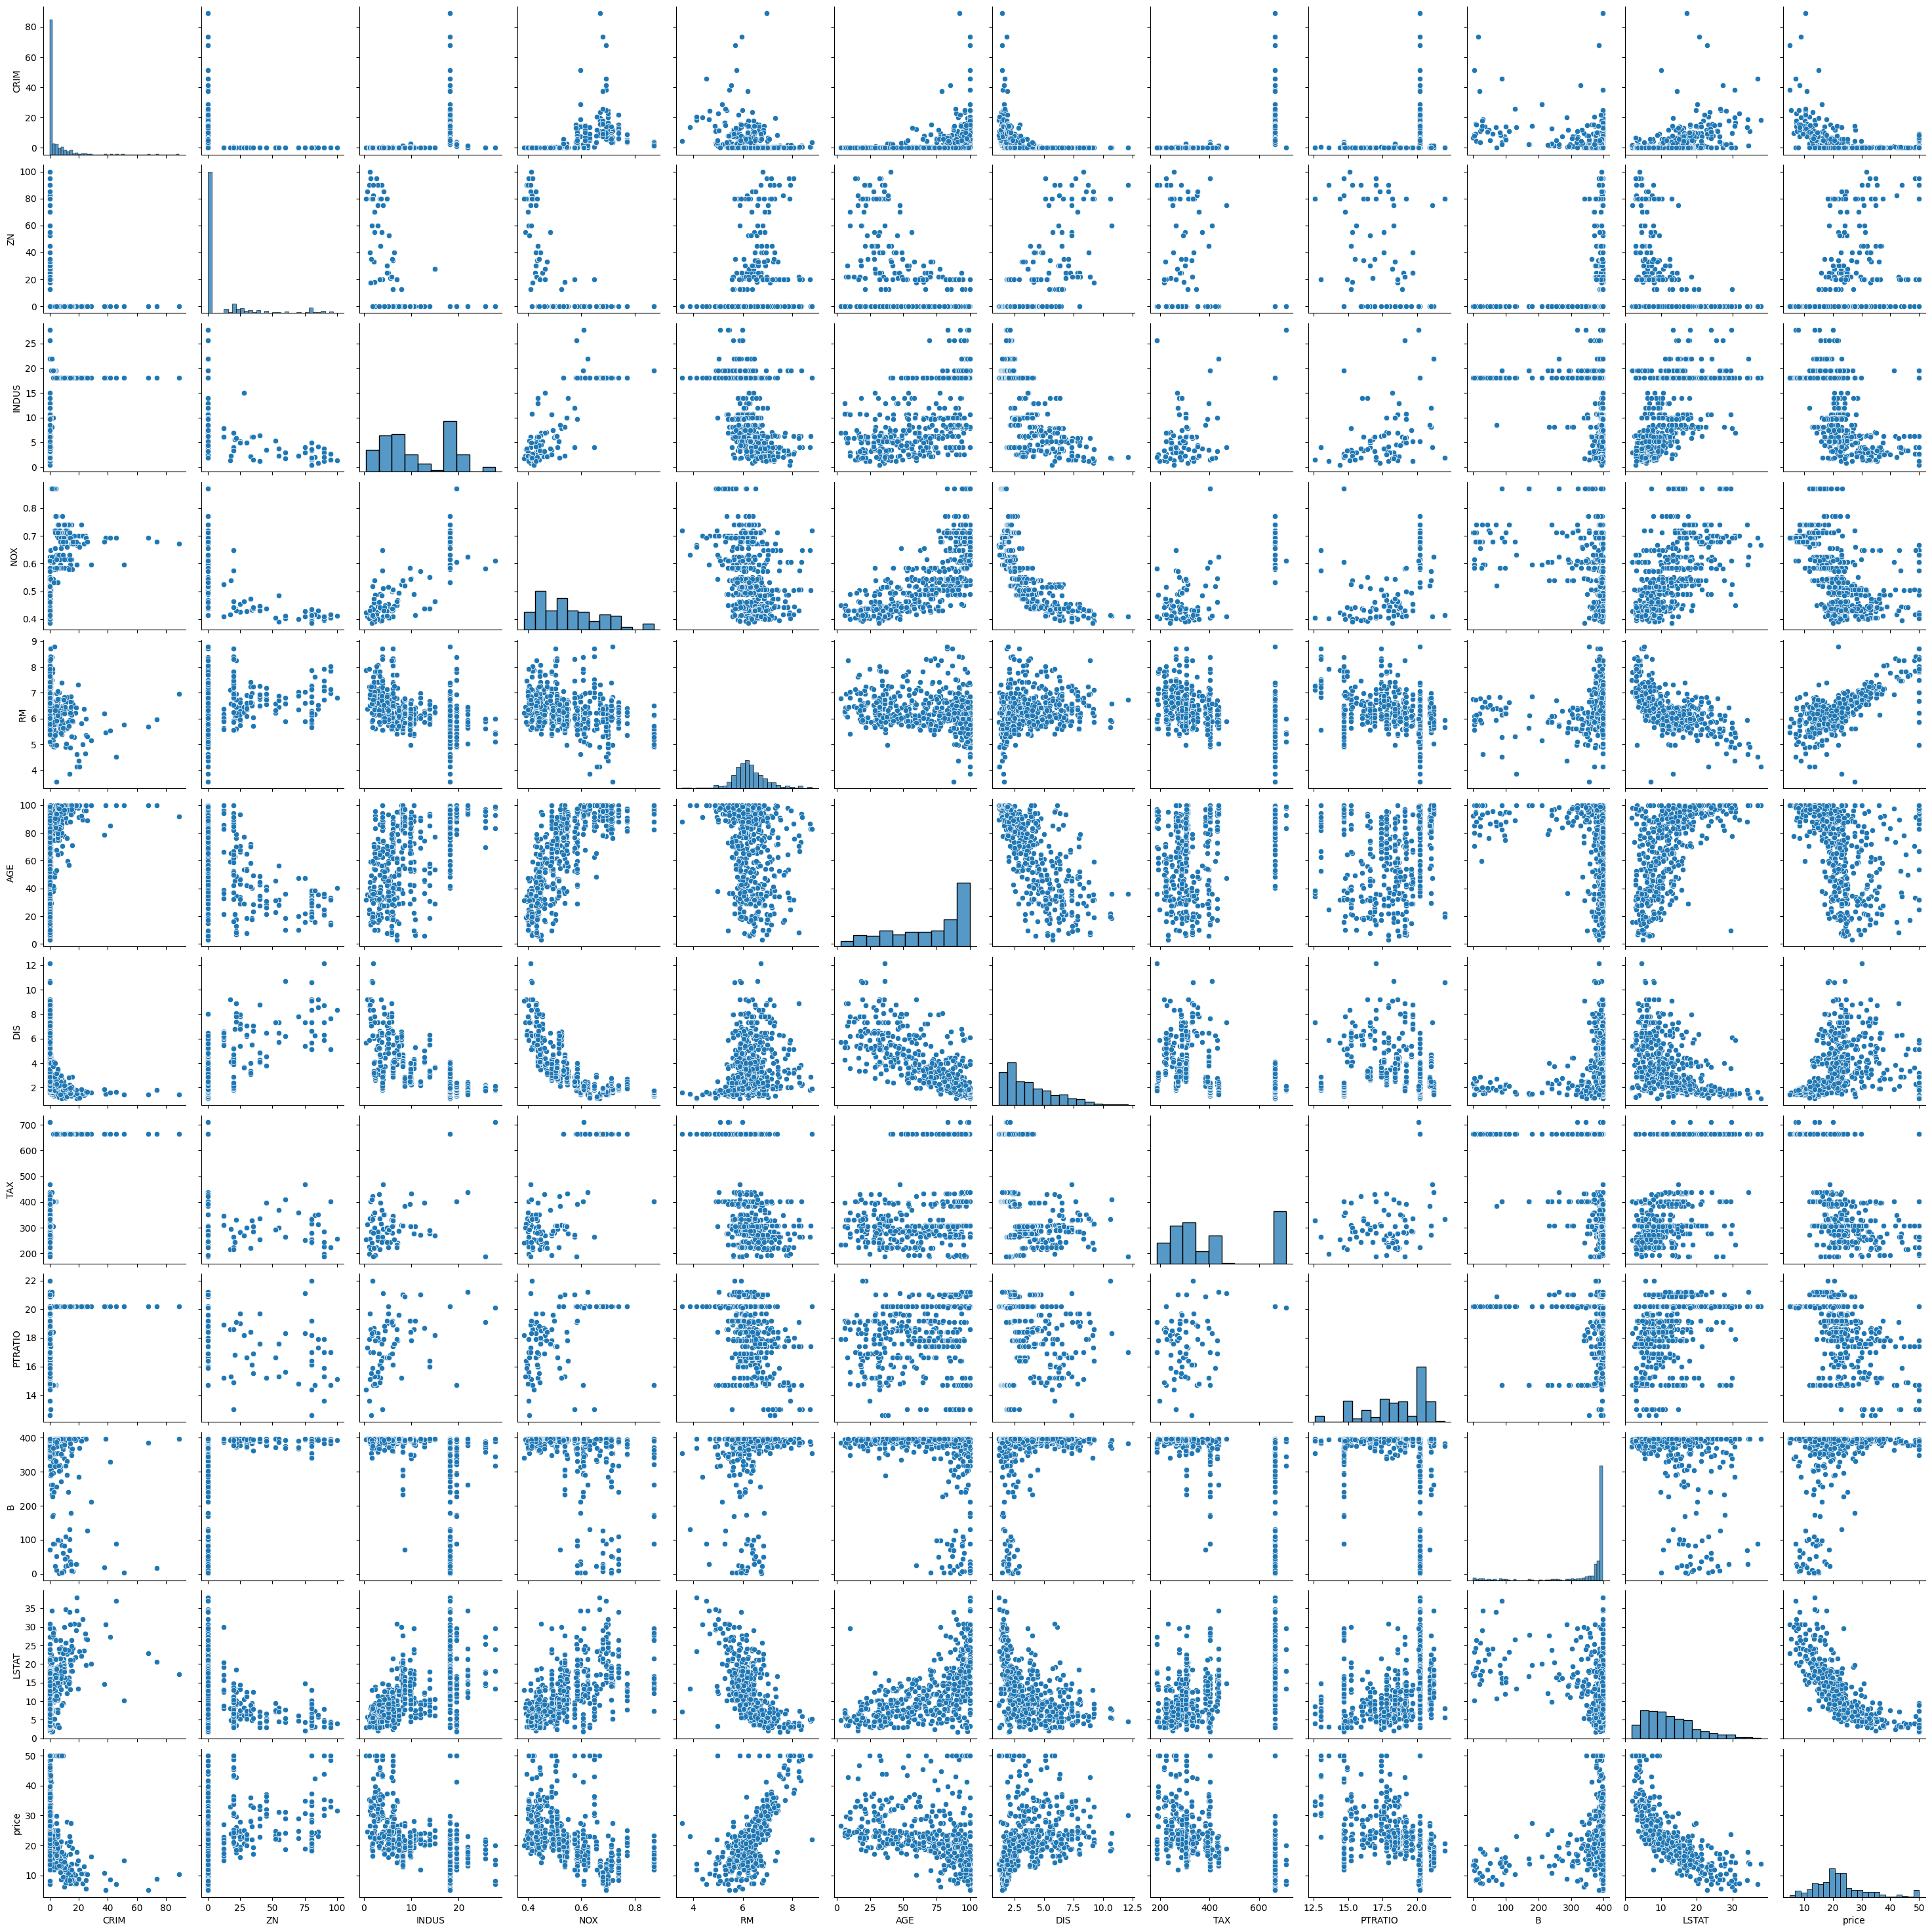

In [17]:
import seaborn as sns
sns.pairplot(dataset)

Text(0, 0.5, 'price')

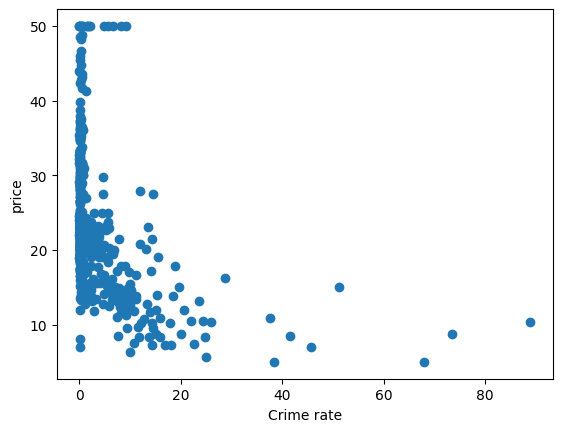

In [21]:
import matplotlib.pyplot as plt

plt.scatter(dataset['CRIM'], dataset['price'])
plt.xlabel("Crime rate")
plt.ylabel("price")

<Axes: xlabel='RM', ylabel='price'>

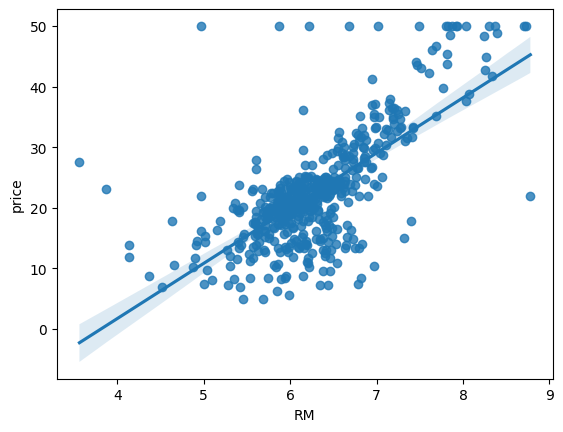

In [24]:
import seaborn as sns
sns.regplot(x="RM", y = "price", data=dataset)

<Axes: xlabel='PTRATIO', ylabel='price'>

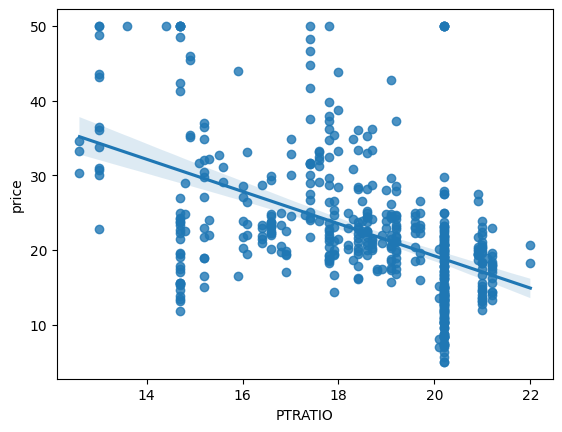

In [25]:
import seaborn as sns
sns.regplot(x="PTRATIO", y = "price", data=dataset)

MODEL CREATION

INDEPENDATE AND DEPENDATE FEATURES - remove dependent features

In [26]:
x = dataset.iloc[:, :-1]
y = dataset.iloc[:,-1]

In [27]:
x.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


Train-Test-Split


In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [32]:
x_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21
116,0.13158,0.0,10.01,0,0.547,6.176,72.5,2.7301,6,432.0,17.8,393.30,12.04
45,0.17142,0.0,6.91,0,0.448,5.682,33.8,5.1004,3,233.0,17.9,396.90,10.21
16,1.05393,0.0,8.14,0,0.538,5.935,29.3,4.4986,4,307.0,21.0,386.85,6.58
468,15.57570,0.0,18.10,0,0.580,5.926,71.0,2.9084,24,666.0,20.2,368.74,18.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0,0.520,5.836,91.9,2.2110,5,384.0,20.9,395.67,18.66
270,0.29916,20.0,6.96,0,0.464,5.856,42.1,4.4290,3,223.0,18.6,388.65,13.00
348,0.01501,80.0,2.01,0,0.435,6.635,29.7,8.3440,4,280.0,17.0,390.94,5.99
435,11.16040,0.0,18.10,0,0.740,6.629,94.6,2.1247,24,666.0,20.2,109.85,23.27


In [33]:
y_test

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
441    17.1
23     14.5
225    50.0
433    14.3
447    12.6
Name: price, Length: 152, dtype: float64

Standerd Scalling Before Model trainning

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [35]:
x.train=scaler.fit_transform(x_train)

C:\Users\Nensi\AppData\Local\Temp\ipykernel_3988\1110160926.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  x.train=scaler.fit_transform(x_train)


In [36]:
x.test=scaler.fit_transform(x_test)

C:\Users\Nensi\AppData\Local\Temp\ipykernel_3988\757047073.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  x.test=scaler.fit_transform(x_test)


In [37]:
x_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21
116,0.13158,0.0,10.01,0,0.547,6.176,72.5,2.7301,6,432.0,17.8,393.30,12.04
45,0.17142,0.0,6.91,0,0.448,5.682,33.8,5.1004,3,233.0,17.9,396.90,10.21
16,1.05393,0.0,8.14,0,0.538,5.935,29.3,4.4986,4,307.0,21.0,386.85,6.58
468,15.57570,0.0,18.10,0,0.580,5.926,71.0,2.9084,24,666.0,20.2,368.74,18.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0,0.520,5.836,91.9,2.2110,5,384.0,20.9,395.67,18.66
270,0.29916,20.0,6.96,0,0.464,5.856,42.1,4.4290,3,223.0,18.6,388.65,13.00
348,0.01501,80.0,2.01,0,0.435,6.635,29.7,8.3440,4,280.0,17.0,390.94,5.99
435,11.16040,0.0,18.10,0,0.740,6.629,94.6,2.1247,24,666.0,20.2,109.85,23.27


In [38]:
x_test

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,0.09178,0.0,4.05,0,0.510,6.416,84.1,2.6463,5,296.0,16.6,395.50,9.04
274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254.0,17.6,396.90,3.53
491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711.0,20.1,390.11,18.07
72,0.09164,0.0,10.81,0,0.413,6.065,7.8,5.2873,4,305.0,19.2,390.91,5.52
452,5.09017,0.0,18.10,0,0.713,6.297,91.8,2.3682,24,666.0,20.2,385.09,17.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,9.72418,0.0,18.10,0,0.740,6.406,97.2,2.0651,24,666.0,20.2,385.96,19.52
23,0.98843,0.0,8.14,0,0.538,5.813,100.0,4.0952,4,307.0,21.0,394.54,19.88
225,0.52693,0.0,6.20,0,0.504,8.725,83.0,2.8944,8,307.0,17.4,382.00,4.63
433,5.58107,0.0,18.10,0,0.713,6.436,87.9,2.3158,24,666.0,20.2,100.19,16.22


Model Training

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
regression = LinearRegression()

In [49]:
regression.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.13, 0.04, 0.05,...,-0.91, 0.01,-0.55]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['CRIM','ZN','INDUS',...,'PTRATIO','B','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,31.63
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


In [44]:
print(regression.coef_)

[-1.33470103e-01  3.58089136e-02  4.95226452e-02  3.11983512e+00
 -1.54170609e+01  4.05719923e+00 -1.08208352e-02 -1.38599824e+00
  2.42727340e-01 -8.70223437e-03 -9.10685208e-01  1.17941159e-02
 -5.47113313e-01]


In [46]:
print(regression.intercept_)

31.631084035694286


Prediction With Data

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 1. First, make sure everything is a float
x_train = x_train.astype(float)
x_test = x_test.astype(float)

# 2. Fit and transform the TRAINING data (use an underscore!)
x_train = scaler.fit_transform(x_train)

# 3. ONLY transform the TEST data (do not fit!) (use an underscore!)
x_test = scaler.transform(x_test)


In [51]:
reg_pred = regression.predict(x_test)

c:\Users\Nensi\Desktop\House Price Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [53]:
reg_pred

array([ 39.04510117,  60.42575198,  22.02289883,  47.430121  ,
        10.1616309 ,  45.98703853,  29.39817931,  20.34394737,
        33.58450536,  25.63499523,  42.39562987,  32.27903318,
         1.00944614,  45.07566074,  34.5423654 ,  27.44677663,
        25.44436869,   3.20179647,  58.41352445,   9.46303961,
        42.37404921,  46.58419491,  27.48901084,  29.95070711,
         8.25867331,  22.13881748,  43.64434339,  12.27858124,
        48.97369018,  24.08176873,  33.87244894,  39.07743367,
        22.20083392,  -1.9167273 ,  25.13149437, -11.70565654,
        47.14474806,  32.12111249,  49.53779011,  48.2884569 ,
        21.31738594,  45.65860749,  60.36435916,  44.01843254,
        40.9881054 ,   8.8508354 ,  28.03876746,  49.32573671,
        26.66649042,  36.0500866 ,  32.84426687,  50.41647771,
        30.38287896,  38.04835436,  38.20450015,  26.92558411,
         6.43042073,  52.55331249,  44.71563496,  39.81047075,
        43.91161996,  53.89783927,  40.33026117,  27.18

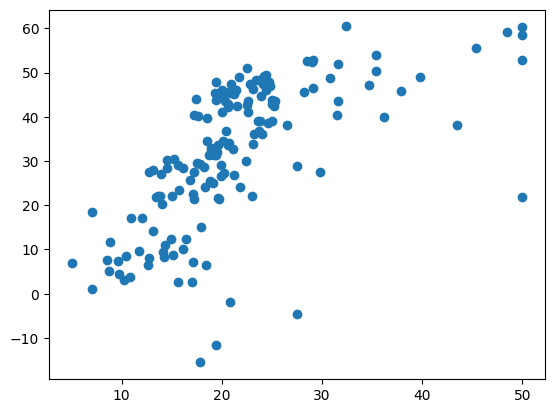

In [55]:
plt.scatter(y_test, reg_pred)

In [57]:
  ##residuals == errors
residuals = y_test-reg_pred

In [58]:
residuals

173   -15.445101
274   -28.025752
491    -8.422899
72    -24.630121
452     5.938369
         ...    
441     9.943703
23    -13.858065
225    -2.827429
433     3.283115
447     6.171468
Name: price, Length: 152, dtype: float64

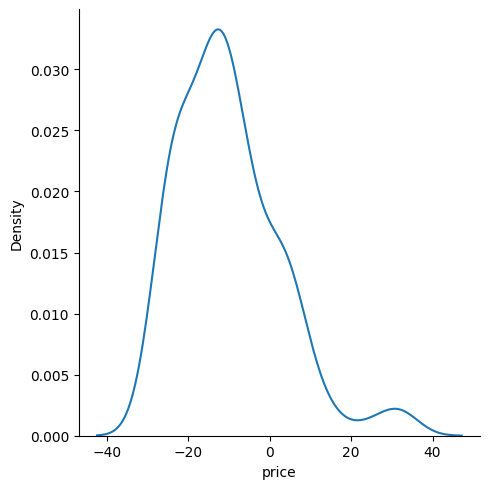

In [60]:
sns.displot(residuals, kind="kde")

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline 

In [25]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------------------------------------------
# Make sure `y_test` (true values) and `reg_pred` (model predictions)
# are already defined in the notebook before you run this cell.
# -----------------------------------------------------------------

# 1️⃣ Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, reg_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# 2️⃣ Mean Squared Error (MSE)
mse = mean_squared_error(y_test, reg_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# 3️⃣ Root Mean Squared Error (RMSE) – square‑root of MSE
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


Mean Absolute Error (MAE): 33.4505
Mean Squared Error (MSE): 2195.7451
Root Mean Squared Error (RMSE): 46.8588


In [26]:
from sklearn.metrics import r2_score

# -------------------------------------------------
# Compute R‑squared (coefficient of determination)
# -------------------------------------------------
# y_test  – true target values
# reg_pred – predictions from your regression model
r2 = r2_score(y_test, reg_pred)

print(f"R‑squared (R²): {r2:.4f}")



R‑squared (R²): 0.9665


In [29]:
from sklearn.metrics import r2_score
import numpy as np

# -------------------------------------------------
# Adjusted R‑squared – safe version
# -------------------------------------------------
# y_test  – true target values (array‑like)
# reg_pred – predictions from your regression model
# X_test  – feature matrix used for prediction (needed for # of predictors)

# 1️⃣ Ordinary R²
r2 = r2_score(y_test, reg_pred)

# 2️⃣ Sample size (n) and number of predictors (p)
n = len(y_test)                 # observations in the test set
p = X_test.shape[1]             # number of feature columns

# 3️⃣ Compute adjusted R² only when the denominator is > 0
denom = (n - p - 1)

if denom > 0:
    adj_r2 = 1 - (1 - r2) * (n - 1) / denom
    adj_msg = f"{adj_r2:.4f}"
else:
    # Not enough degrees‑of‑freedom to compute a meaningful adjusted R²
    adj_r2 = np.nan
    adj_msg = "undefined (n ≤ p + 1 – not enough test samples)"

print(f"R‑squared (R²)          : {r2:.4f}")
print(f"Adjusted R‑squared     : {adj_msg}")


R‑squared (R²)          : 0.9665
Adjusted R‑squared     : undefined (n ≤ p + 1 – not enough test samples)


New Data Prediction

In [32]:
# -------------------------------------------------
# Load the classic Boston housing dataset (via OpenML)
# -------------------------------------------------
from sklearn.datasets import fetch_openml
import pandas as pd

# The dataset name on OpenML is "Boston"
boston = fetch_openml(name="Boston", version=1, as_frame=True)

# Convert to NumPy arrays if you prefer the scikit‑learn style
X = boston.data.values          # feature matrix
y = boston.target.values        # target vector

# -------------------------------------------------
# Inspect the shape and a sample row
# -------------------------------------------------
print("Feature matrix shape :", X.shape)          # (n_samples, n_features)
print("Target vector shape  :", y.shape)          # (n_samples,)
print("\nFirst sample (row 0):")
print(pd.Series(X[0], index=boston.feature_names))


Feature matrix shape : (506, 13)
Target vector shape  : (506,)

First sample (row 0):
CRIM       0.00632
ZN            18.0
INDUS         2.31
CHAS             0
NOX          0.538
RM           6.575
AGE           65.2
DIS           4.09
RAD              1
TAX          296.0
PTRATIO       15.3
B            396.9
LSTAT         4.98
dtype: object


In [37]:
# -------------------------------------------------
# 1️⃣ Load Boston dataset (if not already loaded)
# -------------------------------------------------
from sklearn.datasets import fetch_openml
import pandas as pd

boston = fetch_openml(name="Boston", version=1, as_frame=True)
X = boston.data.values          # feature matrix (numpy array)

# -------------------------------------------------
# 2️⃣ Fit a scaler on the whole dataset (or on your train split)
# -------------------------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)                   # learn mean & std from the data

# -------------------------------------------------
# 3️⃣ Transform the first sample
# -------------------------------------------------
first_sample = X[0].reshape(1, -1)          # shape (1, n_features)
scaled_sample = scaler.transform(first_sample)

print("Original sample shape :", first_sample.shape)   # (1, n_features)
print("Scaled sample shape   :", scaled_sample.shape) # (1, n_features)
print("Scaled values :", scaled_sample)


Original sample shape : (1, 13)
Scaled sample shape   : (1, 13)
Scaled values : [[-0.41978194  0.28482986 -1.2879095  -0.27259857 -0.14421743  0.41367189
  -0.12001342  0.1402136  -0.98284286 -0.66660821 -1.45900038  0.44105193
  -1.0755623 ]]


In [38]:
sample_shape = boston.data.iloc[0].values.reshape(1, -1).shape
print("Shape after reshape:", sample_shape)   # Expected output: (1, n_features)

Shape after reshape: (1, 13)


pickling the model file for deployement

In [ ]:

import pickle

In [45]:
import pickle

# Replace `model` with whatever variable holds your fitted regressor
with open('regmodel.pkl', 'wb') as f:
    pickle.dump(model, f)       # <-- correct object

print("Model saved to 'regmodel.pkl'")


Model saved to 'regmodel.pkl'


In [47]:
pickle.model=pickle.load(open('regmodel.pkl','rb'))

In [52]:
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------
# 1️⃣ Load Boston data (you can keep using the same subset you trained on)
# -------------------------------------------------
boston = fetch_openml(name="Boston", version=1, as_frame=True)

# Example: use three features – replace with the columns you actually used
features = ['RM', 'LSTAT', 'PTRATIO']          # <-- adjust if needed
X = boston.data[features].values
y = boston.target.values

# -------------------------------------------------
# 2️⃣ Train / fit the model (if you already have a trained model, skip this)
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# -------------------------------------------------
# 3️⃣ Fit the scaler on the training data (same columns)
# -------------------------------------------------
scaler = StandardScaler()
scaler.fit(X_train)

# -------------------------------------------------
# 4️⃣ Save both objects to pickle files in the current folder
# -------------------------------------------------
with open('regmodel.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved to 'regmodel.pkl'")
print("✅ Scaler saved to 'scaler.pkl'")


✅ Model saved to 'regmodel.pkl'
✅ Scaler saved to 'scaler.pkl'
